<a href="https://colab.research.google.com/github/sachini9-git/northstar-databases-analytics/blob/main/04_mongodb_pymongo_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Section 03: MongoDB Atlas and PyMongo Implementation
# Step 1: Install and Load Required Packages
# ============================================================
# Purpose:
# Install and load the Python packages required to connect
# Google Colab with MongoDB Atlas and perform MongoDB operations.
#
# Assignment link:
# This supports MongoDB development using PyMongo and Python.
# ============================================================

!pip install "pymongo[srv]" certifi pandas matplotlib seaborn

from pymongo import MongoClient
from getpass import getpass
from urllib.parse import quote_plus
import certifi
import pandas as pd
import json
import os
import pprint
import matplotlib.pyplot as plt
import seaborn as sns

print("Required packages loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 28.6 MB/s eta 0:00:00
Required packages loaded successfully.


In [2]:
# ============================================================
# Step 2: Connect Google Colab to MongoDB Atlas
# ============================================================
# Purpose:
# Establish a secure connection between this Colab notebook and
# the MongoDB Atlas cluster using PyMongo.
#
# Security note:
# The password is entered using getpass(), so it will not be
# displayed in the notebook output.
# ============================================================

username = "sachiniwijayasekar_db_user"

password = getpass("Enter MongoDB database password: ")
encoded_password = quote_plus(password)

connection_string = (
    f"mongodb+srv://{username}:{encoded_password}"
    f"@northstarcluster.xwhce8r.mongodb.net/"
    f"?retryWrites=true&w=majority&appName=NorthStarCluster"
)

client = MongoClient(
    connection_string,
    tlsCAFile=certifi.where()
)

client.admin.command("ping")

print("Connected to MongoDB Atlas successfully.")

Enter MongoDB database password: ··········
Connected to MongoDB Atlas successfully.


In [3]:
# ============================================================
# Step 3: Select MongoDB Database
# ============================================================
# Purpose:
# Select the MongoDB Atlas database that will store the NorthStar
# source collections, integrated service case documents, schema
# examples, CRUD demo collections, and aggregation outputs.
# ============================================================

db = client["northstar_analytics"]

print("Database selected: northstar_analytics")

Database selected: northstar_analytics


In [4]:
# ============================================================
# Step 4: Upload NorthStar CSV Datasets into Google Colab
# ============================================================
# Purpose:
# Upload the original NorthStar CSV datasets into Colab before
# converting them into JSON-style MongoDB documents.
#
# Assignment link:
# This supports the MongoDB implementation section by preparing
# source datasets for import into MongoDB Atlas collections.
# ============================================================

from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for file_name in uploaded.keys():
    print(file_name)

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving README.txt to README.txt
Saving vehicles.csv to vehicles.csv
Uploaded files:
app_events.csv
complaints.csv
customers.csv
data_dictionary.csv
deliveries.csv
drivers.csv
hubs.csv
incidents.csv
orders.csv
README.txt
vehicles.csv


In [5]:
# ============================================================
# Step 5: Convert CSV Files into JSON-Style Documents
#         and Import into MongoDB Collections
# ============================================================
# Purpose:
# Convert each uploaded CSV dataset into JSON-style MongoDB
# document records and insert them into separate MongoDB Atlas
# collections using a reusable import function.
#
# Assignment link:
# This supports MongoDB implementation by creating separate
# collections for each NorthStar source dataset.
# ============================================================

dataset_files = {
    "customers": "customers.csv",
    "orders": "orders.csv",
    "deliveries": "deliveries.csv",
    "drivers": "drivers.csv",
    "vehicles": "vehicles.csv",
    "hubs": "hubs.csv",
    "incidents": "incidents.csv",
    "complaints": "complaints.csv",
    "app_events": "app_events.csv",
    "data_dictionary": "data_dictionary.csv"
}

def insert_json_style_documents(file_name, collection_name):
    """
    Read a CSV file from Colab, convert rows into JSON-style
    MongoDB documents, and insert them into the selected collection.
    """

    if not os.path.exists(file_name):
        raise FileNotFoundError(
            f"{file_name} was not found. Please upload this CSV file into Colab first."
        )

    # Read CSV into pandas
    df = pd.read_csv(file_name)

    # Convert dataframe into JSON-style records
    # NaN values are converted into null-compatible JSON values
    records = json.loads(df.to_json(orient="records"))

    collection = db[collection_name]

    # Clear old records to avoid duplicates if this cell is rerun
    collection.delete_many({})

    # Insert into MongoDB collection
    if len(records) == 1:
        collection.insert_one(records[0])
    elif len(records) > 1:
        collection.insert_many(records)

    return {
        "Collection": collection_name,
        "Source_File": file_name,
        "Documents_Inserted": collection.count_documents({})
    }

import_summary = []

for collection_name, file_name in dataset_files.items():
    import_summary.append(
        insert_json_style_documents(file_name, collection_name)
    )

import_summary_df = pd.DataFrame(import_summary)

import_summary_df

,Collection,Source_File,Documents_Inserted
0,customers,customers.csv,650
1,orders,orders.csv,1250
2,deliveries,deliveries.csv,950
3,drivers,drivers.csv,170
4,vehicles,vehicles.csv,120
5,hubs,hubs.csv,8
6,incidents,incidents.csv,280
7,complaints,complaints.csv,320
8,app_events,app_events.csv,640
9,data_dictionary,data_dictionary.csv,9


In [6]:
# ============================================================
# Step 6: Verify MongoDB Collection Counts
# ============================================================
# Purpose:
# Confirm that each NorthStar source dataset was imported into
# MongoDB Atlas with the expected document count.
# ============================================================

expected_counts = {
    "customers": 650,
    "orders": 1250,
    "deliveries": 950,
    "drivers": 170,
    "vehicles": 120,
    "hubs": 8,
    "incidents": 280,
    "complaints": 320,
    "app_events": 640,
    "data_dictionary": 9
}

verification_summary = []

for collection_name, expected_count in expected_counts.items():
    actual_count = db[collection_name].count_documents({})

    verification_summary.append({
        "Collection": collection_name,
        "Expected_Documents": expected_count,
        "Actual_Documents": actual_count,
        "Status": "Matched" if actual_count == expected_count else "Check Required"
    })

verification_df = pd.DataFrame(verification_summary)

verification_df

,Collection,Expected_Documents,Actual_Documents,Status
0,customers,650,650,Matched
1,orders,1250,1250,Matched
2,deliveries,950,950,Matched
3,drivers,170,170,Matched
4,vehicles,120,120,Matched
5,hubs,8,8,Matched
6,incidents,280,280,Matched
7,complaints,320,320,Matched
8,app_events,640,640,Matched
9,data_dictionary,9,9,Matched


In [7]:
# ============================================================
# Step 8: Print One Full Document per MongoDB Collection
# ============================================================
# Purpose:
# Display one complete sample document from each key MongoDB
# collection to demonstrate the document structure/schema.
#
# Assignment link:
# This supports the MongoDB implementation requirement:
# "Show schema examples / print one full document per collection."
# ============================================================

main_collections = [
    "customers",
    "orders",
    "deliveries",
    "drivers",
    "vehicles",
    "hubs",
    "incidents",
    "complaints",
    "app_events",
    "data_dictionary",
    "service_cases"
]

for collection_name in main_collections:
    print("\n" + "=" * 80)
    print(f"Sample full document from collection: {collection_name}")
    print("=" * 80)

    sample_document = db[collection_name].find_one({}, {"_id": 0})

    if sample_document:
        pprint.pprint(sample_document, sort_dicts=False)
    else:
        print("No documents found in this collection.")


Sample full document from collection: customers
{'customer_id': 'C0001',
 'age': 26,
 'home_zone': 'North',
 'customer_type': 'SME',
 'signup_date': '2024-11-27 04:25:00',
 'loyalty_score': 44.9,
 'app_engagement_score': 69.2,
 'preferred_channel': 'App',
 'account_status': 'Active'}

Sample full document from collection: orders
{'order_id': 'O00001',
 'customer_id': 'C0292',
 'service_type': 'Passenger',
 'order_created_at': '2024-08-20 14:43:00',
 'promised_window_hours': 6,
 'pickup_zone': 'Airport',
 'dropoff_zone': 'South',
 'priority_level': 'Medium',
 'order_value': 126.65,
 'booking_channel': 'App',
 'special_handling_flag': 0}

Sample full document from collection: deliveries
{'delivery_id': 'DL00001',
 'order_id': 'O00938',
 'driver_id': 'D004',
 'vehicle_id': 'V056',
 'hub_id': 'H05',
 'dispatch_time': '2024-06-18 10:57:00',
 'delivery_completed_at': '2024-06-19 09:05:59.904311',
 'delivery_status': 'Failed',
 'route_distance_km': 17.26,
 'manual_route_override_count': 1,
 

In [9]:
# ============================================================
# Step 9: MongoDB Collection Schema Summary
# ============================================================
# Purpose:
# Summarise the number of fields and field names in each MongoDB
# collection based on one sample document.
# ============================================================

schema_summary = []

for collection_name in main_collections:
    sample_document = db[collection_name].find_one({}, {"_id": 0})

    if sample_document:
        schema_summary.append({
            "Collection": collection_name,
            "Document_Count": db[collection_name].count_documents({}),
            "Field_Count": len(sample_document.keys()),
            "Fields": ", ".join(sample_document.keys())
        })

schema_summary_df = pd.DataFrame(schema_summary)

schema_summary_df

,Collection,Document_Count,Field_Count,Fields
0,customers,650,9,"customer_id, age, home_zone, customer_type, si..."
1,orders,1250,11,"order_id, customer_id, service_type, order_cre..."
2,deliveries,950,13,"delivery_id, order_id, driver_id, vehicle_id, ..."
3,drivers,170,8,"driver_id, base_zone, employment_type, years_e..."
4,vehicles,120,8,"vehicle_id, vehicle_type, assigned_zone, commi..."
5,hubs,8,5,"hub_id, hub_name, zone, hub_type, capacity_score"
6,incidents,280,7,"incident_id, delivery_id, incident_type, repor..."
7,complaints,320,10,"complaint_id, customer_id, order_id, complaint..."
8,app_events,640,10,"event_id, customer_id, order_id, event_timesta..."
9,data_dictionary,9,3,"file_name, record_count, description"


In [11]:
# ============================================================
# Step 11: Create NoSQL Nested Schema Example
# ============================================================
# Purpose:
# Create a nested MongoDB document example showing how related
# customer, order, delivery, complaint and incident records can
# be embedded for service case investigation.
#
# Assignment link:
# This supports MongoDB design justification by demonstrating
# embedding vs referencing decisions.
# ============================================================

schema_examples = db["schema_design_examples"]

# Remove old schema example if this cell is rerun
schema_examples.delete_many({
    "schema_name": "customer_order_service_case_schema"
})

# Start from a real order so we know customer_id and order_id exist
sample_order = db["orders"].find_one({}, {"_id": 0})

sample_customer = {}
sample_deliveries = []
sample_complaints = []
sample_incidents = []

if sample_order:
    # Get linked customer
    sample_customer = db["customers"].find_one(
        {"customer_id": sample_order["customer_id"]},
        {"_id": 0}
    )

    # Get linked deliveries
    sample_deliveries = list(
        db["deliveries"].find(
            {"order_id": sample_order["order_id"]},
            {"_id": 0}
        )
    )

    # Get linked complaints
    sample_complaints = list(
        db["complaints"].find(
            {"order_id": sample_order["order_id"]},
            {"_id": 0}
        )
    )

    # Get linked incidents through delivery_id
    delivery_ids = [
        delivery["delivery_id"]
        for delivery in sample_deliveries
        if "delivery_id" in delivery
    ]

    if len(delivery_ids) > 0:
        sample_incidents = list(
            db["incidents"].find(
                {"delivery_id": {"$in": delivery_ids}},
                {"_id": 0}
            )
        )

nested_schema_document = {
    "schema_name": "customer_order_service_case_schema",
    "purpose": "Example embedded MongoDB document for NorthStar service case investigation",
    "design_type": "Hybrid document model",
    "embedding_decision": "Order, deliveries, complaints and incidents are embedded because they are commonly reviewed together during service failure analysis.",
    "referencing_decision": "Customers, hubs, drivers and vehicles can also remain as separate collections because they are reusable operational entities.",
    "customer": sample_customer,
    "service_case": {
        "order": sample_order,
        "deliveries": sample_deliveries,
        "complaints": sample_complaints,
        "incidents": sample_incidents
    }
}

schema_examples.insert_one(nested_schema_document)

schema_result = pd.DataFrame({
    "Collection": ["schema_design_examples"],
    "Schema_Name": ["customer_order_service_case_schema"],
    "Design_Type": ["Hybrid document model"],
    "Main_Document": ["Customer service case"],
    "Embedded_Entities": ["Order, Deliveries, Complaints, Incidents"],
    "Status": ["Nested schema example created successfully"]
})

schema_result

,Collection,Schema_Name,Design_Type,Main_Document,Embedded_Entities,Status
0,schema_design_examples,customer_order_service_case_schema,Hybrid document model,Customer service case,"Order, Deliveries, Complaints, Incidents",Nested schema example created successfully


In [12]:
# ============================================================
# Step 12: Preview Nested Schema Example
# ============================================================
# Purpose:
# Show a summary of the nested schema document created in MongoDB.
# ============================================================

nested_preview = schema_examples.find_one(
    {"schema_name": "customer_order_service_case_schema"},
    {"_id": 0}
)

nested_preview_summary = pd.DataFrame({
    "Schema_Name": [nested_preview["schema_name"]],
    "Customer_ID": [
        nested_preview["customer"].get("customer_id")
        if nested_preview["customer"] else None
    ],
    "Order_ID": [
        nested_preview["service_case"]["order"].get("order_id")
        if nested_preview["service_case"]["order"] else None
    ],
    "Nested_Deliveries": [len(nested_preview["service_case"]["deliveries"])],
    "Nested_Complaints": [len(nested_preview["service_case"]["complaints"])],
    "Nested_Incidents": [len(nested_preview["service_case"]["incidents"])],
    "Design_Type": [nested_preview["design_type"]]
})

nested_preview_summary

,Schema_Name,Customer_ID,Order_ID,Nested_Deliveries,Nested_Complaints,Nested_Incidents,Design_Type
0,customer_order_service_case_schema,C0292,O00001,1,0,0,Hybrid document model


In [13]:
# ============================================================
# Step 14: MongoDB Query 1 - Failed and Delayed Deliveries with Hub Details
# ============================================================
# Purpose:
# Use MongoDB aggregation and $lookup to connect deliveries with
# hub details and identify operational problem cases.
#
# Business justification:
# Failed and delayed deliveries directly indicate service reliability
# issues. Linking them with hub details helps identify where operational
# problems may be concentrated.
# ============================================================

delivery_issue_pipeline = [
    {
        "$match": {
            "delivery_status": {"$in": ["Failed", "Delayed"]}
        }
    },
    {
        "$lookup": {
            "from": "hubs",
            "localField": "hub_id",
            "foreignField": "hub_id",
            "as": "hub_details"
        }
    },
    {
        "$unwind": {
            "path": "$hub_details",
            "preserveNullAndEmptyArrays": True
        }
    },
    {
        "$project": {
            "_id": 0,
            "delivery_id": 1,
            "order_id": 1,
            "driver_id": 1,
            "hub_id": 1,
            "hub_name": "$hub_details.hub_name",
            "zone": "$hub_details.zone",
            "delivery_status": 1,
            "route_distance_km": 1,
            "manual_route_override_count": 1,
            "fuel_or_charge_cost": 1
        }
    },
    {
        "$sort": {
            "manual_route_override_count": -1,
            "route_distance_km": -1
        }
    },
    {
        "$limit": 15
    }
]

delivery_issue_results = list(
    db["deliveries"].aggregate(delivery_issue_pipeline)
)

delivery_issue_df = pd.DataFrame(delivery_issue_results)

delivery_issue_df

,delivery_id,order_id,driver_id,hub_id,delivery_status,route_distance_km,manual_route_override_count,fuel_or_charge_cost,hub_name,zone
0,DL00055,O00819,D069,H04,Delayed,35.07,5,22.20,West Gate,West
1,DL00744,O00899,D052,H06,Delayed,25.36,5,13.11,Airport Hub,Airport
2,DL00881,O00632,D127,H01,Delayed,12.77,5,11.86,North Exchange,North
3,DL00922,O00399,D112,H07,Delayed,12.65,5,14.07,Riverside Hub,Riverside
4,DL00306,O01168,D136,H07,Delayed,34.53,4,19.47,Riverside Hub,Riverside
5,DL00935,O00211,D107,H08,Failed,32.42,4,14.69,Midtown Relay,Central
6,DL00758,O01126,D085,H07,Delayed,21.98,4,17.10,Riverside Hub,Riverside
7,DL00384,O00618,D017,H05,Failed,14.52,4,10.94,Central Core,Central
8,DL00440,O00758,D028,H03,Delayed,10.74,4,9.77,East Dock,East
9,DL00590,O00229,D112,H07,Delayed,7.56,4,12.03,Riverside Hub,Riverside


In [14]:
# ============================================================
# Step 15: MongoDB Query 2 - Hub Performance Summary
# ============================================================
# Purpose:
# Calculate delivery performance by hub using the original
# deliveries and hubs collections.
#
# Business justification:
# This identifies hubs with higher failure and delay rates, supporting
# hub-level service improvement decisions.
# ============================================================

hub_performance_pipeline = [
    {
        "$lookup": {
            "from": "hubs",
            "localField": "hub_id",
            "foreignField": "hub_id",
            "as": "hub_details"
        }
    },
    {
        "$unwind": {
            "path": "$hub_details",
            "preserveNullAndEmptyArrays": True
        }
    },
    {
        "$group": {
            "_id": {
                "hub_id": "$hub_id",
                "hub_name": "$hub_details.hub_name",
                "zone": "$hub_details.zone"
            },
            "total_deliveries": {"$sum": 1},
            "failed_deliveries": {
                "$sum": {
                    "$cond": [{"$eq": ["$delivery_status", "Failed"]}, 1, 0]
                }
            },
            "delayed_deliveries": {
                "$sum": {
                    "$cond": [{"$eq": ["$delivery_status", "Delayed"]}, 1, 0]
                }
            },
            "avg_route_distance_km": {"$avg": "$route_distance_km"},
            "avg_manual_overrides": {"$avg": "$manual_route_override_count"},
            "avg_fuel_charge_cost": {"$avg": "$fuel_or_charge_cost"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "hub_id": "$_id.hub_id",
            "hub_name": "$_id.hub_name",
            "zone": "$_id.zone",
            "total_deliveries": 1,
            "failed_deliveries": 1,
            "delayed_deliveries": 1,
            "avg_route_distance_km": {"$round": ["$avg_route_distance_km", 2]},
            "avg_manual_overrides": {"$round": ["$avg_manual_overrides", 2]},
            "avg_fuel_charge_cost": {"$round": ["$avg_fuel_charge_cost", 2]},
            "failure_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$failed_deliveries", "$total_deliveries"]},
                            100
                        ]
                    },
                    2
                ]
            },
            "delay_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$delayed_deliveries", "$total_deliveries"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },
    {
        "$sort": {
            "failure_rate_percent": -1,
            "delay_rate_percent": -1
        }
    }
]

hub_performance_results = list(
    db["deliveries"].aggregate(hub_performance_pipeline)
)

hub_performance_df = pd.DataFrame(hub_performance_results)

hub_performance_df

,total_deliveries,failed_deliveries,delayed_deliveries,hub_id,hub_name,zone,avg_route_distance_km,avg_manual_overrides,avg_fuel_charge_cost,failure_rate_percent,delay_rate_percent
0,128,26,22,H08,Midtown Relay,Central,12.82,1.11,11.71,20.31,17.19
1,115,23,25,H05,Central Core,Central,14.32,0.95,13.69,20.00,21.74
2,104,15,27,H06,Airport Hub,Airport,14.41,0.91,13.32,14.42,25.96
3,127,16,28,H04,West Gate,West,13.38,0.87,13.17,12.60,22.05
4,136,17,26,H01,North Exchange,North,13.64,1.03,12.76,12.50,19.12
5,115,14,25,H07,Riverside Hub,Riverside,14.29,1.05,12.92,12.17,21.74
6,106,10,26,H02,South Link,South,14.17,0.92,12.57,9.43,24.53
7,119,11,23,H03,East Dock,East,14.52,0.89,12.74,9.24,19.33


In [15]:
# ============================================================
# Step 16: MongoDB Query 3 - Complaint and Compensation by Service Type
# ============================================================
# Purpose:
# Use MongoDB aggregation to analyse complaint and compensation
# patterns by service type.
#
# Business justification:
# This connects service categories with customer dissatisfaction and
# compensation exposure, helping NorthStar prioritise service improvements.
# ============================================================

complaint_service_pipeline = [
    {
        "$lookup": {
            "from": "complaints",
            "localField": "order_id",
            "foreignField": "order_id",
            "as": "complaint_details"
        }
    },
    {
        "$project": {
            "_id": 0,
            "order_id": 1,
            "service_type": 1,
            "complaint_count": {"$size": "$complaint_details"},
            "total_compensation": {
                "$sum": "$complaint_details.compensation_amount"
            }
        }
    },
    {
        "$group": {
            "_id": "$service_type",
            "total_orders": {"$sum": 1},
            "orders_with_complaints": {
                "$sum": {
                    "$cond": [{"$gt": ["$complaint_count", 0]}, 1, 0]
                }
            },
            "total_complaints": {"$sum": "$complaint_count"},
            "total_compensation": {"$sum": "$total_compensation"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "service_type": "$_id",
            "total_orders": 1,
            "orders_with_complaints": 1,
            "total_complaints": 1,
            "total_compensation": {"$round": ["$total_compensation", 2]},
            "complaint_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$orders_with_complaints", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },
    {
        "$sort": {
            "complaint_rate_percent": -1
        }
    }
]

complaint_service_results = list(
    db["orders"].aggregate(complaint_service_pipeline)
)

complaint_service_df = pd.DataFrame(complaint_service_results)

complaint_service_df

,total_orders,orders_with_complaints,total_complaints,service_type,total_compensation,complaint_rate_percent
0,297,72,83,Retail,1486.14,24.24
1,139,33,37,Medical,740.01,23.74
2,341,77,84,Passenger,1657.53,22.58
3,308,69,77,Parcel,1463.65,22.40
4,165,34,39,Business,810.86,20.61


In [16]:
# ============================================================
# Step 16: MongoDB Query 3 - Complaint and Compensation by Service Type
# ============================================================
# Purpose:
# Use MongoDB aggregation to analyse complaint and compensation
# patterns by service type.
#
# Business justification:
# This connects service categories with customer dissatisfaction and
# compensation exposure, helping NorthStar prioritise service improvements.
# ============================================================

complaint_service_pipeline = [
    {
        "$lookup": {
            "from": "complaints",
            "localField": "order_id",
            "foreignField": "order_id",
            "as": "complaint_details"
        }
    },
    {
        "$project": {
            "_id": 0,
            "order_id": 1,
            "service_type": 1,
            "complaint_count": {"$size": "$complaint_details"},
            "total_compensation": {
                "$sum": "$complaint_details.compensation_amount"
            }
        }
    },
    {
        "$group": {
            "_id": "$service_type",
            "total_orders": {"$sum": 1},
            "orders_with_complaints": {
                "$sum": {
                    "$cond": [{"$gt": ["$complaint_count", 0]}, 1, 0]
                }
            },
            "total_complaints": {"$sum": "$complaint_count"},
            "total_compensation": {"$sum": "$total_compensation"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "service_type": "$_id",
            "total_orders": 1,
            "orders_with_complaints": 1,
            "total_complaints": 1,
            "total_compensation": {"$round": ["$total_compensation", 2]},
            "complaint_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$orders_with_complaints", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },
    {
        "$sort": {
            "complaint_rate_percent": -1
        }
    }
]

complaint_service_results = list(
    db["orders"].aggregate(complaint_service_pipeline)
)

complaint_service_df = pd.DataFrame(complaint_service_results)

complaint_service_df

,total_orders,orders_with_complaints,total_complaints,service_type,total_compensation,complaint_rate_percent
0,297,72,83,Retail,1486.14,24.24
1,139,33,37,Medical,740.01,23.74
2,341,77,84,Passenger,1657.53,22.58
3,308,69,77,Parcel,1463.65,22.40
4,165,34,39,Business,810.86,20.61


In [17]:
# ============================================================
# Step 17: Verify Integrated service_cases Collection
# ============================================================
# Purpose:
# Confirm that the integrated analytics-ready service_cases
# collection exists before performing real-data CRUD operations.
# ============================================================

service_cases = db["service_cases"]

service_cases_count = service_cases.count_documents({})

service_cases_check = pd.DataFrame({
    "Collection": ["service_cases"],
    "Purpose": ["Integrated analytics-ready service case documents"],
    "Document_Count": [service_cases_count],
    "Status": ["Ready" if service_cases_count > 0 else "Check Required"]
})

service_cases_check

,Collection,Purpose,Document_Count,Status
0,service_cases,Integrated analytics-ready service case documents,1250,Ready


In [18]:
# ============================================================
# Step 18: MongoDB CRUD CREATE - Insert Real Case into Review Collection
# ============================================================
# Purpose:
# Demonstrate CREATE operation by copying one real high-risk service
# case from service_cases into a separate service_case_reviews collection.
#
# Business justification:
# In real operations, high-risk service cases can be copied into a
# review collection for investigation without changing the original data.
# ============================================================

service_case_reviews = db["service_case_reviews"]

# Remove old review demo record if this cell is rerun
service_case_reviews.delete_many({"review_case_id": "REVIEW_CASE_001"})

# Select the highest-risk real service case from the integrated collection
real_case = service_cases.find_one(
    {},
    sort=[("service_risk_score", -1)]
)

if real_case is None:
    raise ValueError("No records found in service_cases. Please check the service_cases collection.")

# Remove MongoDB _id so this can be inserted as a new document
real_case.pop("_id", None)

# Add review workflow fields
real_case["review_case_id"] = "REVIEW_CASE_001"
real_case["review_status"] = "Pending Review"
real_case["review_priority"] = "High"
real_case["review_reason"] = "High service risk score selected for operational review"
real_case["review_source"] = "Copied from real service_cases collection"

insert_result = service_case_reviews.insert_one(real_case)

insert_summary = pd.DataFrame({
    "Operation": ["CREATE / Insert"],
    "Review_Case_ID": ["REVIEW_CASE_001"],
    "Original_Order_ID": [real_case.get("order_id")],
    "Service_Type": [real_case.get("service_type")],
    "Service_Risk_Score": [real_case.get("service_risk_score")],
    "Inserted_Document_ID": [str(insert_result.inserted_id)]
})

insert_summary

,Operation,Review_Case_ID,Original_Order_ID,Service_Type,Service_Risk_Score,Inserted_Document_ID
0,CREATE / Insert,REVIEW_CASE_001,O00128,Medical,10,6a04aaa11e19db09c9dcda0f


In [19]:
# ============================================================
# Step 19: MongoDB CRUD READ - Retrieve Review Case
# ============================================================
# Purpose:
# Demonstrate READ operation by retrieving the inserted review case.
# ============================================================

review_case = list(
    service_case_reviews.find(
        {"review_case_id": "REVIEW_CASE_001"},
        {
            "_id": 0,
            "review_case_id": 1,
            "order_id": 1,
            "customer_id": 1,
            "service_type": 1,
            "delivery_status": 1,
            "hub_name": 1,
            "zone": 1,
            "service_risk_score": 1,
            "risk_category": 1,
            "review_status": 1,
            "review_priority": 1
        }
    )
)

review_case_df = pd.DataFrame(review_case)

review_case_df

,order_id,customer_id,service_type,delivery_status,hub_name,zone,service_risk_score,risk_category,review_case_id,review_status,review_priority
0,O00128,C0611,Medical,Delayed,Riverside Hub,Riverside,10,High Risk,REVIEW_CASE_001,Pending Review,High


In [20]:
# ============================================================
# Step 20: MongoDB CRUD UPDATE - Update Review Case
# ============================================================
# Purpose:
# Demonstrate UPDATE operation by changing the operational review
# status and priority of the copied real service case.
# ============================================================

update_result = service_case_reviews.update_one(
    {"review_case_id": "REVIEW_CASE_001"},
    {
        "$set": {
            "review_status": "Reviewed by operations team",
            "review_priority": "Critical",
            "review_action": "Escalated to hub performance manager"
        }
    }
)

updated_review_case = list(
    service_case_reviews.find(
        {"review_case_id": "REVIEW_CASE_001"},
        {
            "_id": 0,
            "review_case_id": 1,
            "order_id": 1,
            "hub_name": 1,
            "delivery_status": 1,
            "service_risk_score": 1,
            "risk_category": 1,
            "review_status": 1,
            "review_priority": 1,
            "review_action": 1
        }
    )
)

update_summary = pd.DataFrame({
    "Operation": ["UPDATE"],
    "Matched_Documents": [update_result.matched_count],
    "Modified_Documents": [update_result.modified_count]
})

display(update_summary)
pd.DataFrame(updated_review_case)

,Operation,Matched_Documents,Modified_Documents
0,UPDATE,1,1


,order_id,delivery_status,hub_name,service_risk_score,risk_category,review_case_id,review_status,review_priority,review_action
0,O00128,Delayed,Riverside Hub,10,High Risk,REVIEW_CASE_001,Reviewed by operations team,Critical,Escalated to hub performance manager


In [21]:
# ============================================================
# Step 21: MongoDB CRUD DELETE - Remove Review Case
# ============================================================
# Purpose:
# Demonstrate DELETE operation by removing only the copied review case.
# The original service case remains unchanged in service_cases.
# ============================================================

delete_result = service_case_reviews.delete_one(
    {"review_case_id": "REVIEW_CASE_001"}
)

remaining_review_records = service_case_reviews.count_documents(
    {"review_case_id": "REVIEW_CASE_001"}
)

delete_summary = pd.DataFrame({
    "Operation": ["DELETE"],
    "Deleted_Documents": [delete_result.deleted_count],
    "Remaining_Review_Records": [remaining_review_records]
})

delete_summary

,Operation,Deleted_Documents,Remaining_Review_Records
0,DELETE,1,0


In [22]:
# ============================================================
# Step 22: MongoDB CRUD UPDATE MANY - Safe Customer Demo Collection
# ============================================================
# Purpose:
# Demonstrate update_many() using a copied demo collection.
#
# Important:
# This does not modify the original customers collection.
# ============================================================

customers_crud_demo = db["customers_crud_demo"]

# Reset demo collection
customers_crud_demo.delete_many({})

customer_records = list(db["customers"].find({}, {"_id": 0}))

if len(customer_records) > 0:
    customers_crud_demo.insert_many(customer_records)

update_many_result = customers_crud_demo.update_many(
    {"customer_id": {"$exists": True}},
    {
        "$set": {
            "crud_demo_status": "Reviewed for customer service analysis"
        }
    }
)

update_many_summary = pd.DataFrame({
    "Operation": ["UPDATE MANY"],
    "Demo_Collection": ["customers_crud_demo"],
    "Modified_Documents": [update_many_result.modified_count],
    "Total_Demo_Records": [customers_crud_demo.count_documents({})],
    "Original_Customers_Unchanged": [db["customers"].count_documents({})]
})

update_many_summary

,Operation,Demo_Collection,Modified_Documents,Total_Demo_Records,Original_Customers_Unchanged
0,UPDATE MANY,customers_crud_demo,650,650,650


In [23]:
# ============================================================
# Step 23: MongoDB CRUD DELETE MANY - Safe Delivery Demo Collection
# ============================================================
# Purpose:
# Demonstrate delete_many() using a copied demo collection.
#
# Important:
# This deletes only from deliveries_crud_demo, not from the original
# deliveries collection.
# ============================================================

deliveries_crud_demo = db["deliveries_crud_demo"]

# Reset demo collection
deliveries_crud_demo.delete_many({})

delivery_records = list(db["deliveries"].find({}, {"_id": 0}))

if len(delivery_records) > 0:
    deliveries_crud_demo.insert_many(delivery_records)

delete_many_result = deliveries_crud_demo.delete_many(
    {"delivery_status": "Failed"}
)

delete_many_summary = pd.DataFrame({
    "Operation": ["DELETE MANY"],
    "Demo_Collection": ["deliveries_crud_demo"],
    "Deleted_Documents": [delete_many_result.deleted_count],
    "Remaining_Demo_Deliveries": [deliveries_crud_demo.count_documents({})],
    "Original_Deliveries_Unchanged": [db["deliveries"].count_documents({})]
})

delete_many_summary

,Operation,Demo_Collection,Deleted_Documents,Remaining_Demo_Deliveries,Original_Deliveries_Unchanged
0,DELETE MANY,deliveries_crud_demo,132,818,950


In [25]:
# ============================================================
# Step 24: MongoDB Aggregation 1 - Hub-Level Service Risk Summary
# ============================================================
# Purpose:
# Use MongoDB aggregation to calculate hub-level service risk,
# failure, delay, complaint, incident, route distance and cost KPIs.
#
# Business justification:
# This helps NorthStar identify which hubs are creating higher
# operational risk and should be prioritised for management review.
# ============================================================

service_cases = db["service_cases"]

hub_risk_pipeline = [
    {
        "$match": {
            "hub_name": {"$ne": "No Linked Hub"}
        }
    },
    {
        "$group": {
            "_id": {
                "hub_name": "$hub_name",
                "zone": "$zone"
            },
            "total_orders": {"$sum": 1},
            "failed_deliveries": {"$sum": "$is_failed"},
            "delayed_deliveries": {"$sum": "$is_delayed"},
            "complaint_cases": {"$sum": "$has_complaint"},
            "incident_cases": {"$sum": "$has_incident"},
            "avg_service_risk_score": {"$avg": "$service_risk_score"},
            "avg_route_distance_km": {"$avg": "$route_distance_km"},
            "avg_fuel_charge_cost": {"$avg": "$fuel_or_charge_cost"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "hub_name": "$_id.hub_name",
            "zone": "$_id.zone",
            "total_orders": 1,
            "failed_deliveries": 1,
            "delayed_deliveries": 1,
            "complaint_cases": 1,
            "incident_cases": 1,
            "avg_service_risk_score": {"$round": ["$avg_service_risk_score", 2]},
            "avg_route_distance_km": {"$round": ["$avg_route_distance_km", 2]},
            "avg_fuel_charge_cost": {"$round": ["$avg_fuel_charge_cost", 2]},
            "failure_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$failed_deliveries", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            },
            "delay_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$delayed_deliveries", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },
    {
        "$sort": {
            "avg_service_risk_score": -1
        }
    }
]

hub_risk_summary = list(service_cases.aggregate(hub_risk_pipeline))

hub_risk_summary_df = pd.DataFrame(hub_risk_summary)

hub_risk_summary_df

,total_orders,failed_deliveries,delayed_deliveries,complaint_cases,incident_cases,hub_name,zone,avg_service_risk_score,avg_route_distance_km,avg_fuel_charge_cost,failure_rate_percent,delay_rate_percent
0,115,23,25,28,34,Central Core,Central,3.47,14.32,13.69,20.00,21.74
1,128,26,22,31,32,Midtown Relay,Central,3.04,12.82,11.71,20.31,17.19
2,104,15,27,21,25,Airport Hub,Airport,3.02,14.41,13.32,14.42,25.96
3,115,14,25,30,32,Riverside Hub,Riverside,3.00,14.29,12.92,12.17,21.74
4,127,16,28,26,33,West Gate,West,2.87,13.38,13.17,12.60,22.05
5,119,11,23,31,32,East Dock,East,2.72,14.52,12.74,9.24,19.33
6,136,17,26,26,30,North Exchange,North,2.71,13.64,12.76,12.50,19.12
7,106,10,26,16,30,South Link,South,2.71,14.17,12.57,9.43,24.53


In [26]:
# ============================================================
# Step 25: MongoDB Aggregation 2 - Service-Type Risk Summary
# ============================================================
# Purpose:
# Use MongoDB aggregation to analyse risk, complaints, incidents,
# failures, delays, compensation and cost by service type.
#
# Business justification:
# This helps NorthStar identify which service categories create
# higher customer dissatisfaction, compensation exposure and
# operational risk.
# ============================================================

service_type_pipeline = [
    {
        "$group": {
            "_id": "$service_type",
            "total_orders": {"$sum": 1},
            "failed_deliveries": {"$sum": "$is_failed"},
            "delayed_deliveries": {"$sum": "$is_delayed"},
            "complaint_cases": {"$sum": "$has_complaint"},
            "incident_cases": {"$sum": "$has_incident"},
            "total_compensation": {"$sum": "$total_compensation"},
            "avg_service_risk_score": {"$avg": "$service_risk_score"},
            "avg_fuel_charge_cost": {"$avg": "$fuel_or_charge_cost"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "service_type": "$_id",
            "total_orders": 1,
            "failed_deliveries": 1,
            "delayed_deliveries": 1,
            "complaint_cases": 1,
            "incident_cases": 1,
            "total_compensation": {"$round": ["$total_compensation", 2]},
            "avg_service_risk_score": {"$round": ["$avg_service_risk_score", 2]},
            "avg_fuel_charge_cost": {"$round": ["$avg_fuel_charge_cost", 2]},
            "failure_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$failed_deliveries", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            },
            "delay_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$delayed_deliveries", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            },
            "complaint_rate_percent": {
                "$round": [
                    {
                        "$multiply": [
                            {"$divide": ["$complaint_cases", "$total_orders"]},
                            100
                        ]
                    },
                    2
                ]
            }
        }
    },
    {
        "$sort": {
            "avg_service_risk_score": -1
        }
    }
]

service_type_summary = list(service_cases.aggregate(service_type_pipeline))

service_type_summary_df = pd.DataFrame(service_type_summary)

service_type_summary_df

,total_orders,failed_deliveries,delayed_deliveries,complaint_cases,incident_cases,service_type,total_compensation,avg_service_risk_score,avg_fuel_charge_cost,failure_rate_percent,delay_rate_percent,complaint_rate_percent
0,165,25,28,34,41,Business,810.86,2.62,10.04,15.15,16.97,20.61
1,297,28,50,72,66,Retail,1486.14,2.42,9.79,9.43,16.84,24.24
2,139,16,22,33,23,Medical,740.01,2.34,9.92,11.51,15.83,23.74
3,341,38,53,77,62,Passenger,1657.53,2.28,9.53,11.14,15.54,22.58
4,308,25,49,69,56,Parcel,1463.65,2.24,9.77,8.12,15.91,22.40


In [27]:
# ============================================================
# Step 26: MongoDB Aggregation 3 - Risk Category Distribution
# ============================================================
# Purpose:
# Count the number of service case documents in each risk category.
#
# Business justification:
# This gives management a quick overview of how many service cases
# require low, medium or high levels of operational attention.
# ============================================================

risk_category_pipeline = [
    {
        "$group": {
            "_id": "$risk_category",
            "total_cases": {"$sum": 1},
            "avg_service_risk_score": {"$avg": "$service_risk_score"}
        }
    },
    {
        "$project": {
            "_id": 0,
            "risk_category": "$_id",
            "total_cases": 1,
            "avg_service_risk_score": {"$round": ["$avg_service_risk_score", 2]}
        }
    },
    {
        "$sort": {
            "avg_service_risk_score": -1
        }
    }
]

risk_category_summary = list(service_cases.aggregate(risk_category_pipeline))

risk_category_summary_df = pd.DataFrame(risk_category_summary)

risk_category_summary_df

,total_cases,risk_category,avg_service_risk_score
0,154,High Risk,6.79
1,306,Medium Risk,3.93
2,790,Low Risk,0.88


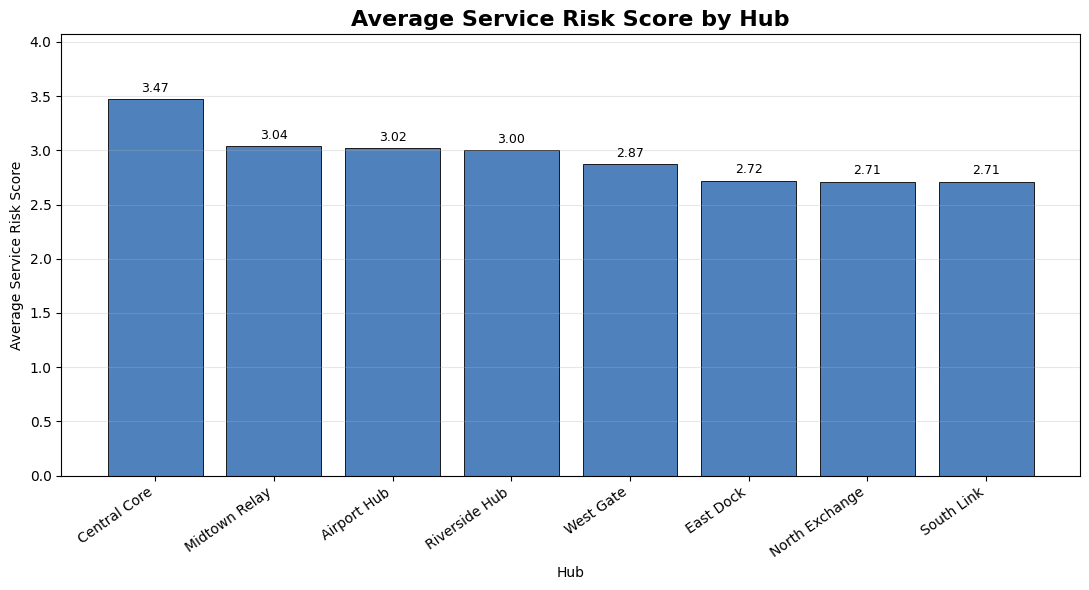

In [42]:
# ============================================================
# Step 27: MongoDB Visualisation 1 - Average Service Risk Score by Hub
# ============================================================
# Purpose:
# Visualise MongoDB aggregation results using a vertical bar chart
# to compare average service risk score across hubs.
#
# Business justification:
# This helps NorthStar identify which hubs should be prioritised
# for operational review based on service risk.
# ============================================================

hub_chart_df = hub_risk_summary_df.sort_values(
    by="avg_service_risk_score",
    ascending=False
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    hub_chart_df["hub_name"],
    hub_chart_df["avg_service_risk_score"],
    color="#4F81BD",
    edgecolor="black",
    linewidth=0.6
)

plt.title(
    "Average Service Risk Score by Hub",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Hub")
plt.ylabel("Average Service Risk Score")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.04,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.ylim(0, hub_chart_df["avg_service_risk_score"].max() + 0.6)
plt.tight_layout()
plt.savefig("mongodb_hub_risk_score_vertical.png", dpi=200, bbox_inches="tight")
plt.show()

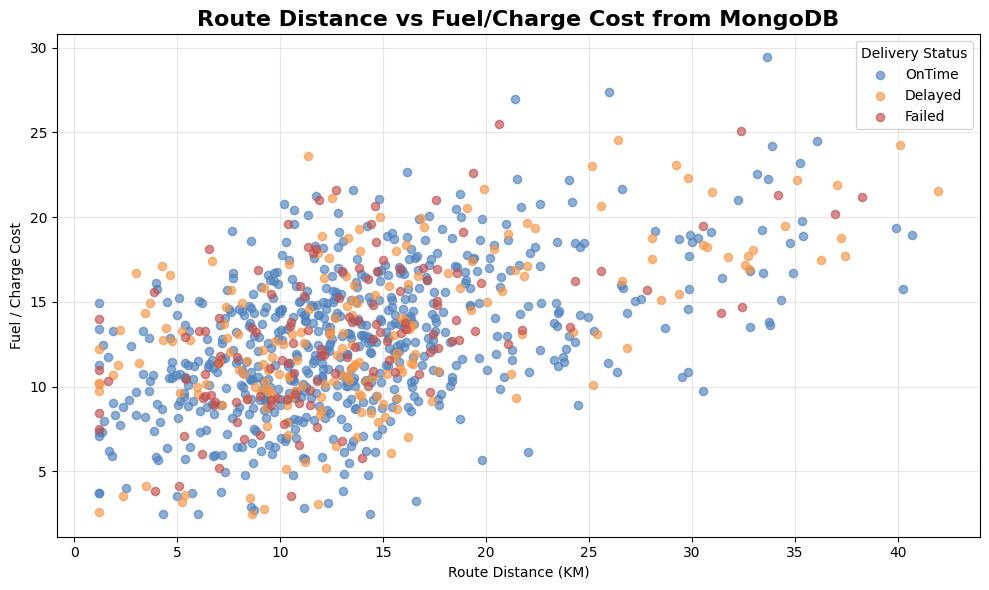

In [34]:
# ============================================================
# Step 28B: MongoDB Visualisation 3 - Route Distance vs Fuel/Charge Cost
# ============================================================
# Purpose:
# Retrieve delivery records from MongoDB and visualise the relationship
# between route distance and fuel/charge cost.
#
# Business justification:
# This checks whether longer routes are associated with higher delivery
# cost, which supports NorthStar's cost escalation investigation.
# ============================================================

deliveries_mongo_df = pd.DataFrame(
    list(
        db["deliveries"].find(
            {},
            {
                "_id": 0,
                "route_distance_km": 1,
                "fuel_or_charge_cost": 1,
                "delivery_status": 1
            }
        )
    )
)

deliveries_mongo_df["route_distance_km"] = pd.to_numeric(
    deliveries_mongo_df["route_distance_km"],
    errors="coerce"
)

deliveries_mongo_df["fuel_or_charge_cost"] = pd.to_numeric(
    deliveries_mongo_df["fuel_or_charge_cost"],
    errors="coerce"
)

scatter_df = deliveries_mongo_df.dropna(
    subset=["route_distance_km", "fuel_or_charge_cost", "delivery_status"]
)

status_colours = {
    "OnTime": "#4F81BD",
    "Delayed": "#F79646",
    "Failed": "#C0504D"
}

plt.figure(figsize=(10, 6))

for status, colour in status_colours.items():
    subset = scatter_df[scatter_df["delivery_status"] == status]
    plt.scatter(
        subset["route_distance_km"],
        subset["fuel_or_charge_cost"],
        label=status,
        alpha=0.65,
        s=35,
        color=colour
    )

plt.title(
    "Route Distance vs Fuel/Charge Cost from MongoDB",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Route Distance (KM)")
plt.ylabel("Fuel / Charge Cost")
plt.legend(title="Delivery Status")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("mongodb_route_distance_vs_cost_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

In [36]:
# ============================================================
# Step 29: Explain Plan Before Indexing
# ============================================================
# Purpose:
# Analyse how MongoDB executes a service risk query before adding
# custom indexes.
#
# Assignment link:
# This supports query optimisation by recording the baseline
# execution plan and document scanning behaviour.
# ============================================================

service_cases = db["service_cases"]

# Drop existing custom indexes to create a clean "before indexing" baseline.
# MongoDB keeps the default _id index automatically.
service_cases.drop_indexes()

# Use the highest-risk hub from the aggregation result to make sure
# the optimisation query returns meaningful records.
top_hub_name = hub_risk_summary_df.sort_values(
    by="avg_service_risk_score",
    ascending=False
).iloc[0]["hub_name"]

query_filter = {
    "risk_category": {"$in": ["Medium Risk", "High Risk"]},
    "hub_name": top_hub_name
}

query_projection = {
    "_id": 0,
    "order_id": 1,
    "customer_id": 1,
    "service_type": 1,
    "delivery_status": 1,
    "hub_name": 1,
    "service_risk_score": 1,
    "risk_category": 1
}

query_sort = {
    "service_risk_score": -1
}

explain_before = db.command(
    "explain",
    {
        "find": "service_cases",
        "filter": query_filter,
        "projection": query_projection,
        "sort": query_sort
    },
    verbosity="executionStats"
)

before_stats = explain_before["executionStats"]

before_summary = pd.DataFrame({
    "Stage": ["Before Indexing"],
    "Query_Hub": [top_hub_name],
    "Documents_Returned": [before_stats.get("nReturned")],
    "Documents_Examined": [before_stats.get("totalDocsExamined")],
    "Index_Keys_Examined": [before_stats.get("totalKeysExamined")],
    "Execution_Time_ms": [before_stats.get("executionTimeMillis")]
})

before_summary

,Stage,Query_Hub,Documents_Returned,Documents_Examined,Index_Keys_Examined,Execution_Time_ms
0,Before Indexing,Central Core,66,1250,0,2


In [37]:
# ============================================================
# Step 30: Create Indexes for Query Optimisation
# ============================================================
# Purpose:
# Create indexes on fields commonly used for filtering, grouping,
# and sorting service-risk queries.
#
# Business justification:
# Indexes reduce unnecessary document scanning and support faster
# operational lookup for high-risk service cases.
# ============================================================

# Index 1: supports risk-based lookup by hub and score sorting
service_cases.create_index(
    [
        ("risk_category", 1),
        ("hub_name", 1),
        ("service_risk_score", -1)
    ],
    name="idx_risk_hub_score"
)

# Index 2: supports service-type complaint and incident analysis
service_cases.create_index(
    [
        ("service_type", 1),
        ("has_complaint", 1),
        ("has_incident", 1)
    ],
    name="idx_service_complaint_incident"
)

# Index 3: supports delivery status and hub-level operational queries
service_cases.create_index(
    [
        ("delivery_status", 1),
        ("hub_name", 1)
    ],
    name="idx_status_hub"
)

index_list = list(service_cases.list_indexes())

index_summary = pd.DataFrame([
    {
        "Index_Name": index["name"],
        "Index_Keys": str(index["key"])
    }
    for index in index_list
])

index_summary

,Index_Name,Index_Keys
0,_id_,"SON([('_id', 1)])"
1,idx_risk_hub_score,"SON([('risk_category', 1), ('hub_name', 1), ('..."
2,idx_service_complaint_incident,"SON([('service_type', 1), ('has_complaint', 1)..."
3,idx_status_hub,"SON([('delivery_status', 1), ('hub_name', 1)])"


In [39]:
# ============================================================
# Step 31: Explain Plan After Indexing
# ============================================================
# Purpose:
# Re-run the same query after indexing to compare document scanning,
# index usage and execution time.
# ============================================================

explain_after = db.command(
    "explain",
    {
        "find": "service_cases",
        "filter": query_filter,
        "projection": query_projection,
        "sort": query_sort,
        "hint": "idx_risk_hub_score"
    },
    verbosity="executionStats"
)

after_stats = explain_after["executionStats"]

after_summary = pd.DataFrame({
    "Stage": ["After Indexing"],
    "Query_Hub": [top_hub_name],
    "Documents_Returned": [after_stats.get("nReturned")],
    "Documents_Examined": [after_stats.get("totalDocsExamined")],
    "Index_Keys_Examined": [after_stats.get("totalKeysExamined")],
    "Execution_Time_ms": [after_stats.get("executionTimeMillis")]
})

after_summary

,Stage,Query_Hub,Documents_Returned,Documents_Examined,Index_Keys_Examined,Execution_Time_ms
0,After Indexing,Central Core,66,66,66,1


In [40]:
# ============================================================
# Step 32: Query Optimisation Comparison
# ============================================================
# Purpose:
# Compare MongoDB query execution before and after custom indexing.
# ============================================================

optimisation_comparison = pd.concat(
    [before_summary, after_summary],
    ignore_index=True
)

optimisation_comparison["Document_Scan_Reduction"] = (
    optimisation_comparison["Documents_Examined"].iloc[0]
    - optimisation_comparison["Documents_Examined"]
)

optimisation_comparison

,Stage,Query_Hub,Documents_Returned,Documents_Examined,Index_Keys_Examined,Execution_Time_ms,Document_Scan_Reduction
0,Before Indexing,Central Core,66,1250,0,2,0
1,After Indexing,Central Core,66,66,66,1,1184


In [41]:
# ============================================================
# Step 33: Optimised MongoDB Query Result
# ============================================================
# Purpose:
# Display the actual service cases returned by the optimised indexed
# query.
# ============================================================

optimised_query_result = list(
    service_cases.find(
        query_filter,
        query_projection
    )
    .sort("service_risk_score", -1)
    .hint("idx_risk_hub_score")
    .limit(15)
)

optimised_query_result_df = pd.DataFrame(optimised_query_result)

optimised_query_result_df

,order_id,customer_id,service_type,delivery_status,hub_name,service_risk_score,risk_category
0,O00765,C0187,Retail,Failed,Central Core,9,High Risk
1,O00089,C0339,Medical,Failed,Central Core,8,High Risk
2,O00100,C0300,Passenger,Failed,Central Core,8,High Risk
3,O00439,C0577,Medical,Failed,Central Core,8,High Risk
4,O00618,C0581,Parcel,Failed,Central Core,8,High Risk
5,O00927,C0533,Medical,Failed,Central Core,8,High Risk
6,O00989,C0351,Medical,Failed,Central Core,8,High Risk
7,O01192,C0200,Business,Delayed,Central Core,8,High Risk
8,O00094,C0361,Parcel,Delayed,Central Core,7,High Risk
9,O00282,C0630,Parcel,Delayed,Central Core,7,High Risk
